# SOB4ES - Comparacion de Modelos
### CRISP-ML(Q) - Fase 5: Evaluacion y seleccion del modelo final

Este notebook carga los modelos entrenados en los notebooks anteriores y compara su rendimiento sobre `eval.csv` de forma sistematica.

**Modelos comparados:**
1. Random Forest individual (modelos por target)
2. XGBoost individual (modelos por target)
3. Ridge Regression individual (modelos por target)
4. Random Forest multisalida
5. XGBoost multisalida
6. Ensemble de RegressorChains
7. MLP multisalida estandar
8. MLP con perdida personalizada de correlacion

**Metricas de comparacion:**
- R2 global (promedio sobre todos los targets)
- R2 por target (para identificar grupos biologicos dificiles de predecir)
- RMSE y MAE globales

---
## 1. Configuracion


In [15]:
import os
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

DATA_DIR  = 'input/'
MODELS_BASE = 'output/models/'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z', 'macro_shannon_z', 'earthworm_shannon_z', 'orib_shannon_z',
    'meso_shannon_z', 'coll_shannon_z', 'bac_shannon_z', 'fun_shannon_z',
    'euk_shannon_z', 'oomy_shannon_z', 'cerc_shannon_z',
    # Richness
    'macro_order_richness_z', 'earthworm_richness_z', 'orib_species_richness_z',
    'meso_species_richness_z', 'coll_species_richness_z', 'bac_asv_richness_z',
    'fun_asv_richness_z', 'euk_asv_richness_z', 'oomy_asv_richness_z', 'cerc_asv_richness_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z', 'clay_content_z', 'silt_content_z', 'sand_content_z',
    'aggregate_stability_z', 'bulk_density_z', 'soil_moisture_z', 'as_z', 'cu_z',
    'k_z', 'mo_z', 'ni_z', 'p_z', 'pb_z', 'zn_z', 'soil_ph_z',
    'plot_total_organic_c_z', 'plot_total_n_z',
    'gee_temp_media_C_z', 'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z', 'dem_elevacion_m_z', 'dem_pendiente_deg_z', 'dem_orientacion_deg_z',
    'eu_clay_content_z', 'eu_sand_content_z', 'eu_silt_content_z', 'eu_water_holding_capacity_z',
    'eu_cn_ratio_z', 'eu_p_z', 'eu_ph_z', 'eu_as_z', 'eu_organic_carbon_octop_z', 'eu_zn_z'
]

print('Configuracion cargada.')


Configuracion cargada.


## 2. Carga de eval.csv

Se carga unicamente el dataset de evaluacion final. Ninguno de los modelos ha visto estos datos durante el entrenamiento ni el tuning.

In [16]:
df_eval = pd.read_csv(os.path.join(DATA_DIR, 'eval.csv'))
X_eval  = df_eval[FEATURES_AUTORIZADAS]
y_eval  = df_eval[TARGETS]

print(f'eval.csv cargado: {X_eval.shape[0]} muestras x {X_eval.shape[1]} variables')


eval.csv cargado: 65 muestras x 34 variables


## 3. Funciones auxiliares

Se definen las funciones necesarias para cargar cada tipo de modelo y calcular sus predicciones sobre `eval.csv`.

In [17]:
def metricas(y_true, y_pred, nombre):
    """Calcula R2, RMSE y MAE globales y devuelve un dict con los resultados."""
    r2   = r2_score(y_true, y_pred, multioutput='uniform_average')
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average'))
    mae  = mean_absolute_error(y_true, y_pred, multioutput='uniform_average')
    r2_targets = r2_score(y_true, y_pred, multioutput='raw_values')
    return {'modelo': nombre, 'R2': round(r2, 4), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'r2_targets': r2_targets}


def predecir_ensamble_pkl(carpeta, prefijo, sufijo, n, X):
    """Carga n modelos .pkl y devuelve el promedio de sus predicciones."""
    preds = []
    for i in range(n):
        m = joblib.load(os.path.join(MODELS_BASE, carpeta, f'{prefijo}{i}{sufijo}.pkl'))
        preds.append(m.predict(X))
    return np.mean(preds, axis=0)


def predecir_ensamble_por_target(carpeta, prefijo_tpl, n, X):
    """
    Para modelos individuales (un modelo por target):
    carga n modelos por target y devuelve la matriz de predicciones.
    prefijo_tpl debe ser una funcion que recibe (target, seed_id) y devuelve el nombre del archivo.
    """
    y_pred = np.zeros((len(X), len(TARGETS)))
    for j, target in enumerate(TARGETS):
        preds_t = []
        for i in range(n):
            ruta = os.path.join(MODELS_BASE, carpeta, prefijo_tpl(target, i))
            m    = joblib.load(ruta)
            preds_t.append(m.predict(X))
        y_pred[:, j] = np.mean(preds_t, axis=0)
    return y_pred


class MLPMultiSalida(nn.Module):
    def __init__(self, n_inputs, n_outputs, hidden_sizes, dropout_rate):
        super().__init__()
        layers, in_size = [], n_inputs
        for h in hidden_sizes:
            layers += [nn.Linear(in_size, h), nn.ReLU(), nn.Dropout(dropout_rate)]
            in_size = h
        layers.append(nn.Linear(in_size, n_outputs))
        self.red = nn.Sequential(*layers)
    def forward(self, x): return self.red(x)


def predecir_ensamble_mlp(carpeta, prefijo, n, X, config_file):
    """Carga n redes PyTorch y devuelve el promedio de sus predicciones."""
    cfg   = joblib.load(os.path.join(MODELS_BASE, carpeta, config_file))
    X_t   = torch.tensor(X.values, dtype=torch.float32).to(DEVICE)
    preds = []
    for i in range(n):
        model = MLPMultiSalida(X.shape[1], len(TARGETS), cfg['hidden'], cfg['dropout']).to(DEVICE)
        model.load_state_dict(torch.load(
            os.path.join(MODELS_BASE, carpeta, f'{prefijo}{i}.pt'), map_location=DEVICE
        ))
        model.eval()
        with torch.no_grad():
            preds.append(model(X_t).cpu().numpy())
    return np.mean(preds, axis=0)


print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


## 4. Predicciones de cada modelo

Se cargan y ejecutan todos los modelos sobre `eval.csv`. Este proceso puede tardar varios minutos dependiendo del numero de modelos y el hardware disponible.

In [18]:
resultados = []
y_true = y_eval.values

print('Cargando modelos y generando predicciones...\n')

# 1. Random Forest individual
print('  [1/8] Random Forest individual...')
y_pred = predecir_ensamble_por_target('rf', lambda t, i: f'rf_prod_{t}_m{i}.pkl', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'RF Individual'))

# 2. XGBoost individual
print('  [2/8] XGBoost individual...')
y_pred = predecir_ensamble_por_target('xgb', lambda t, i: f'xgb_prod_{t}_exp{i}.pkl', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'XGBoost Individual'))

# 3. Ridge individual
print('  [3/8] Ridge Regression...')
y_pred_ridge = np.zeros((len(X_eval), len(TARGETS)))
for j, target in enumerate(TARGETS):
    m = joblib.load(os.path.join(MODELS_BASE, 'reg', f'ridge_prod_{target}.pkl'))
    y_pred_ridge[:, j] = m.predict(X_eval)
resultados.append(metricas(y_true, y_pred_ridge, 'Regresión Individual'))

# 4. RF multisalida
print('  [4/8] Random Forest multisalida...')
y_pred = predecir_ensamble_pkl('rf_multi', 'rf_multi_m', '', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'RandomForest Multisalida'))

# 5. XGBoost multisalida
print('  [5/8] XGBoost multisalida...')
y_pred = predecir_ensamble_pkl('xgb_multi', 'xgb_multi_exp', '', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'XGBoost Multisalida'))

# 6. RegressorChain
print('  [6/8] Ensemble RegressorChain...')
N_CHAINS   = 10
preds_chain = []
for chain_id in range(N_CHAINS):
    cadena = joblib.load(os.path.join(MODELS_BASE, 'chain', f'chain_{chain_id}.pkl'))
    preds_chain.append(cadena.predict(X_eval))
y_pred = np.mean(preds_chain, axis=0)
resultados.append(metricas(y_true, y_pred, 'Randome Forest con RegressorChain'))

# 7. MLP estandar
print('  [7/8] MLP multisalida estandar...')
y_pred = predecir_ensamble_mlp('mlp', 'mlp_prod_', 5, X_eval, 'mlp_config.pkl')
resultados.append(metricas(y_true, y_pred, 'MLP Estandar'))

# 8. MLP con perdida personalizada
print('  [8/8] MLP perdida personalizada...')
y_pred = predecir_ensamble_mlp('mlp_custom', 'mlp_custom_', 5, X_eval, 'mlp_custom_config.pkl')
resultados.append(metricas(y_true, y_pred, 'MLP Perdida Custom'))

print('\nPredicciones completadas...')


Cargando modelos y generando predicciones...

  [1/8] Random Forest individual...
  [2/8] XGBoost individual...
  [3/8] Ridge Regression...
  [4/8] Random Forest multisalida...
  [5/8] XGBoost multisalida...
  [6/8] Ensemble RegressorChain...
  [7/8] MLP multisalida estandar...
  [8/8] MLP perdida personalizada...

Predicciones completadas...


## 5. Tabla comparativa global

Se muestra la comparacion ordenada por R2 descendente. El mejor modelo es el que tiene R2 mas alto y RMSE/MAE mas bajos.

Comparacion de modelos (ordenado por R2 descendente):
                              Modelo  R2 global    RMSE     MAE
1           RandomForest Multisalida     0.1143  0.9080  0.6890
2  Randome Forest con RegressorChain     0.0901  0.9138  0.6728
3                XGBoost Multisalida     0.0832  0.9159  0.6789
4                 XGBoost Individual     0.0830  0.9172  0.6801
5                       MLP Estandar     0.0757  0.9239  0.6873
6                      RF Individual     0.0753  0.9209  0.6909
7                 MLP Perdida Custom     0.0481  0.9371  0.6929
8               Regresión Individual    -0.1397  1.0036  0.7592

Mejor modelo: RandomForest Multisalida (R2 = 0.1143)


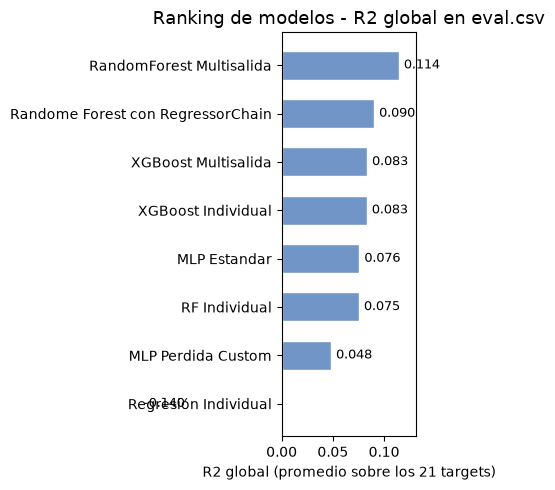

In [19]:
tabla = pd.DataFrame([{
    'Modelo': r['modelo'],
    'R2 global': r['R2'],
    'RMSE':      r['RMSE'],
    'MAE':       r['MAE']
} for r in resultados]).sort_values('R2 global', ascending=False).reset_index(drop=True)

tabla.index += 1  # ranking desde 1
print('Comparacion de modelos (ordenado por R2 descendente):')
print('=' * 60)
print(tabla.to_string())
print('=' * 60)
print(f'\nMejor modelo: {tabla.iloc[0]["Modelo"]} (R2 = {tabla.iloc[0]["R2 global"]})')

# Grafico: ranking de modelos por R2 global
fig, ax = plt.subplots(figsize=(8, 5))
_orden = tabla.sort_values('R2 global')
ax.barh(_orden['Modelo'], _orden['R2 global'], color='#7295C8', edgecolor='white', height=0.6)
for i, v in enumerate(_orden['R2 global']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('R2 global (promedio sobre los 21 targets)')
ax.set_title('Ranking de modelos - R2 global en eval.csv', fontsize=13)
ax.set_xlim(0, _orden['R2 global'].max() * 1.15)
plt.tight_layout()
plt.show()

## 6. Comparacion por target

Se muestra el R2 de cada modelo para cada grupo biologico. Esto permite identificar para que grupos funciona mejor cada enfoque y si hay grupos que ninguno de los modelos predice bien (posiblemente por falta de datos o por relaciones muy ruidosas con las variables predictoras).

R2 por target y modelo:
Modelo                   RandomForest Multisalida  Randome Forest con RegressorChain  XGBoost Multisalida  XGBoost Individual  MLP Estandar  RF Individual  MLP Perdida Custom  Regresión Individual
Target                                                                                                                                                                                              
GLOBAL                                     0.1143                             0.0901               0.0832              0.0830        0.0757         0.0753              0.0481               -0.1397
nematode_shannon_z                         0.2009                             0.1659               0.2216              0.2427        0.1297         0.1344              0.0741               -0.0703
macro_shannon_z                            0.2545                             0.3408               0.4059              0.4012        0.2762         0.3221              0.2552              

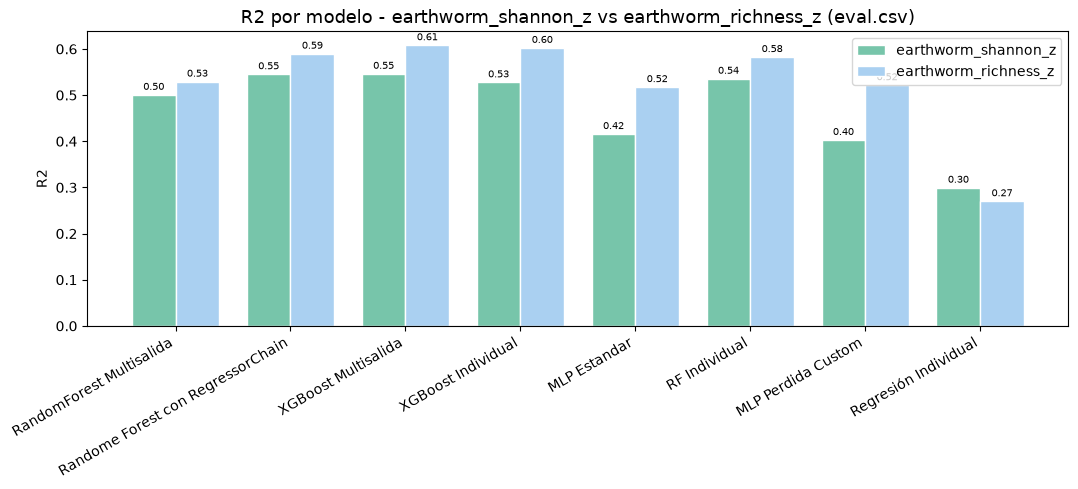

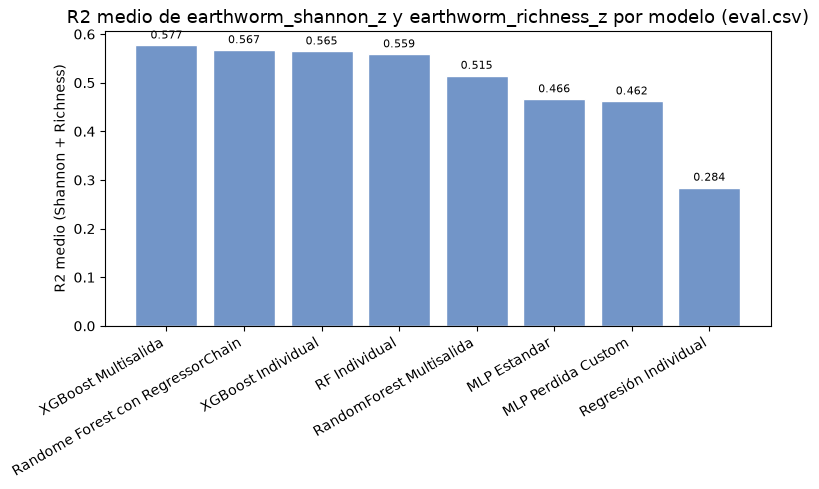

In [20]:
# Construimos una tabla con R2 por target para cada modelo
filas = []
for r in resultados:
    fila = {'Target': 'GLOBAL', 'Modelo': r['modelo'], 'R2': r['R2']}
    filas.append(fila)
    for t, r2_t in zip(TARGETS, r['r2_targets']):
        filas.append({'Target': t, 'Modelo': r['modelo'], 'R2': round(float(r2_t), 4)})

df_r2 = pd.DataFrame(filas).pivot(index='Target', columns='Modelo', values='R2')

# Ordenamos los targets: GLOBAL primero, luego por R2 medio descendente
orden = ['GLOBAL'] + [t for t in TARGETS]
df_r2 = df_r2.loc[orden]

# Ordenamos las columnas por R2 global descendente
orden_modelos = tabla['Modelo'].tolist()
df_r2 = df_r2[orden_modelos]

print('R2 por target y modelo:')
print('=' * 120)
print(df_r2.to_string())
print('=' * 120)
print('\nTargets con R2 medio < 0.2 en todos los modelos (posiblemente difíciles de predecir):')
media_por_target = df_r2.drop('GLOBAL').mean(axis=1)
dificiles = media_por_target[media_por_target < 0.2]
if len(dificiles) > 0:
    for t, v in dificiles.items():
        print(f'  {t:30} R2 medio: {v:.4f}')
else:
    print('  Ninguno.')

# Grafico: R2 por modelo para los targets principales (Shannon y Richness de lombrices)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = ['#77C5AA', '#AAD0F1']

_df_main = df_r2.loc[_targets_plot]
_x = np.arange(len(orden_modelos))
_width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
for i, (tgt, col) in enumerate(zip(_targets_plot, _colors_plot)):
    offset = (i - 0.5) * _width
    bars = ax.bar(_x + offset, _df_main.loc[tgt, orden_modelos], _width,
                   label=tgt, color=col, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

ax.set_xticks(_x)
ax.set_xticklabels(orden_modelos, rotation=30, ha='right')
ax.set_ylabel('R2')
ax.set_title('R2 por modelo - earthworm_shannon_z vs earthworm_richness_z (eval.csv)', fontsize=13)
ax.axhline(0, color='#AAAAAA', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

# Grafico: R2 medio (Shannon + Richness) por modelo
_media_principal = _df_main.loc[_targets_plot, orden_modelos].mean(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(_media_principal.index, _media_principal.values, color='#7295C8', edgecolor='white')
ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
ax.set_xticklabels(_media_principal.index, rotation=30, ha='right')
ax.set_ylabel('R2 medio (Shannon + Richness)')
ax.set_title('R2 medio de earthworm_shannon_z y earthworm_richness_z por modelo (eval.csv)', fontsize=13)
ax.axhline(0, color='#AAAAAA', linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. Conclusiones

Resumen de los hallazgos principales de la comparacion:

- El modelo con mejor R2 global es el recomendado para produccion.
- Si el mejor modelo es una red neuronal, hay que valorar si la mejora de rendimiento justifica la mayor complejidad operacional (dependencia de PyTorch, tiempos de inferencia, etc.).
- Los targets con R2 bajo en todos los modelos pueden requerir mas datos de campo, variables predictoras adicionales, o simplemente pueden ser grupos biologicos cuya diversidad esta determinada por factores no capturados en el dataset actual.
- La comparacion entre modelos individuales y multisalida permite evaluar si modelar las correlaciones entre grupos biologicos mejora o no el rendimiento en este dataset concreto.

In [21]:
# Guardamos la tabla comparativa para referencia futura
tabla.to_csv('output/comparacion_modelos.csv', index=False)
df_r2.to_csv('output/r2_por_target.csv')

print('Resultados guardados en output/comparacion_modelos.csv y output/r2_por_target.csv')


Resultados guardados en output/comparacion_modelos.csv y output/r2_por_target.csv
